<div style="background:linear-gradient(135deg,#0f1117 0%,#1a1d27 60%,#12182b 100%);
border-radius:16px;padding:40px 48px;border:1px solid #2a2d3e;margin-bottom:8px">
<h1 style="color:#7c9ef8;font-size:2.2em;margin:0 0 8px 0;font-weight:800;letter-spacing:-0.5px">
🧬 Immune Cell Type Classifier</h1>
<h3 style="color:#a0aec0;font-weight:400;margin:0 0 20px 0;font-size:1.1em">
Human Immune Multiomics Atlas &nbsp;·&nbsp; End-to-End ML Pipeline</h3>
<div style="display:flex;gap:10px;flex-wrap:wrap">
<span style="background:#1e3a5f;color:#7c9ef8;padding:4px 14px;border-radius:20px;font-size:0.85em;border:1px solid #2a4a7f">scRNA-seq</span>
<span style="background:#1e3a5f;color:#7c9ef8;padding:4px 14px;border-radius:20px;font-size:0.85em;border:1px solid #2a4a7f">XGBoost</span>
<span style="background:#1e3a5f;color:#7c9ef8;padding:4px 14px;border-radius:20px;font-size:0.85em;border:1px solid #2a4a7f">Optuna</span>
<span style="background:#1e3a5f;color:#7c9ef8;padding:4px 14px;border-radius:20px;font-size:0.85em;border:1px solid #2a4a7f">SHAP</span>
<span style="background:#1e3a5f;color:#7c9ef8;padding:4px 14px;border-radius:20px;font-size:0.85em;border:1px solid #2a4a7f">Scanpy</span>
<span style="background:#1a2e1a;color:#68d391;padding:4px 14px;border-radius:20px;font-size:0.85em;border:1px solid #276227">Multi-class · 8 Cell Types</span>
</div>
</div>

## 📋 Project Overview

| | |
|:---|:---|
| **Dataset** | [Human Immune Multiomics Atlas](https://www.kaggle.com/datasets/qasimhu/human-immune-multiomics-atlas) |
| **Task** | Multi-class immune cell type classification from scRNA-seq gene expression |
| **Cell Types** | CD4+ T · CD8+ T · NK · B cell · Monocyte · DC · Treg · Plasma |
| **Best Model** | XGBoost (Optuna Bayesian-tuned, 50 trials) |
| **Metric** | Macro F1 · ROC-AUC (One-vs-Rest) |
| **Explainability** | SHAP TreeExplainer — per-class feature attribution |

### Pipeline Architecture
```
Raw scRNA-seq (.h5ad)
   │
   ▼
QC Filtering → Normalization (log1p) → HVG Selection (2000 genes) → Scale
   │
   ▼
[Visualisation only]  Scanpy PCA (all data) → UMAP
   │
   ▼
Train / Test Split  (80 / 20, stratified)
   ├─ Train set ──▶ sklearn PCA fit  (50 PCs)  ──▶ X_train  [leakage-free]
   └─ Test  set ──▶ PCA transform only          ──▶ X_test
   │
   ▼
Model Benchmark — 5-fold Stratified CV on X_train only
   Logistic Regression · Random Forest · XGBoost · MLP
   │
   ▼
Optuna Bayesian Tuning  (50 trials · TPE + MedianPruner · X_train only)
   8-param search space (n_estimators excluded — set by early stopping)
   │
   ▼
Final XGBoost
   Phase 1 — early-stopping probe on 10 % val split → best_n trees
   Phase 2 — retrain on full X_train for best_n rounds
   │
   ▼
Evaluation: Macro F1 · ROC-AUC · Confusion Matrix · Per-class metrics
   │
   ▼
SHAP Explainability → Global + per-class feature attribution
   │
   ▼
Artifacts saved: xgb_final_model.pkl · pca_ml.pkl · label_encoder.pkl
```


---
## ⚙️ Section 1 — Environment Setup

In [1]:
# Install packages not pre-installed on Kaggle
import subprocess, sys

packages = [
    "xgboost>=2.0",   # pin version — Kaggle pre-installs xgboost but
                      # an unpinned reinstall may silently downgrade the GPU-tested build
    "scanpy>=1.9",    # single-cell analysis
    "anndata>=0.9",   # AnnData format
    "scikit-misc>=0.3",  # required for sc.pp.highly_variable_genes(flavor="seurat")
    "optuna>=3.0",    # Bayesian hyperparameter tuning
    "shap>=0.44",     # explainability (>= 0.44 for unified callable API)
    # leidenalg and python-igraph removed — only needed for Leiden clustering,
    # which is not used in this notebook (sc.tl.umap is used instead).
]

for pkg in packages:
    result = subprocess.run(
        [sys.executable, "-m", "pip", "install", pkg, "-q", "--no-warn-script-location"],
        capture_output=True, text=True
    )
    status = "✅" if result.returncode == 0 else "❌"
    print(f"{status} {pkg}")

print("\n✅ Environment ready")


✅ xgboost>=2.0
✅ scanpy>=1.9
✅ anndata>=0.9
✅ scikit-misc>=0.3
✅ optuna>=3.0
✅ shap>=0.44

✅ Environment ready


---
## 📦 Section 2 — Imports & Configuration

In [2]:
import warnings
# Suppress known-noisy warnings from scanpy/anndata internals only.
# Broad filterwarnings("ignore") is avoided so meaningful deprecation
# warnings (e.g. SHAP API changes, sklearn future warnings) remain visible.
warnings.filterwarnings("ignore", category=FutureWarning,  module="scanpy")
warnings.filterwarnings("ignore", category=FutureWarning,  module="anndata")
warnings.filterwarnings("ignore", category=UserWarning,    module="anndata")
# sklearn DeprecationWarning narrowed to validation utils only — preserves
# warnings from model/splitter APIs where future-breaking changes are more likely.
warnings.filterwarnings("ignore", category=DeprecationWarning, module="sklearn.utils.validation")

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import scanpy as sc
import anndata as ad

from pathlib import Path
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.preprocessing import LabelEncoder, label_binarize
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, f1_score
)

import joblib
import xgboost as xgb
import shap
import optuna
from optuna.samplers import TPESampler
from optuna.importance import get_param_importances

optuna.logging.set_verbosity(optuna.logging.WARNING)

# Suppress scanpy hints (verbosity=3 by default) — errors + warnings only
sc.settings.verbosity = 1

# ── Global config ──────────────────────────────────────────────────────────
RANDOM_STATE = 42
# Use default_rng for all numpy random ops — avoids confusion with the legacy
# np.random.seed() which seeds a separate global RNG.
RNG = np.random.default_rng(RANDOM_STATE)

DATA_PATH = Path("/kaggle/input/human-immune-multiomics-atlas")
OUT_DIR   = Path("/kaggle/working/outputs")
FIG_DIR   = Path("/kaggle/working/figures")
OUT_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)

# ── Plotting style ─────────────────────────────────────────────────────────
plt.rcParams.update({
    "figure.facecolor": "#0f1117",
    "axes.facecolor":   "#1a1d27",
    "axes.edgecolor":   "#444",
    "axes.labelcolor":  "white",
    "xtick.color":      "white",
    "ytick.color":      "white",
    "text.color":       "white",
    "grid.color":       "#2a2d3e",
    "grid.alpha":       0.4,
    "font.family":      "DejaVu Sans",
})

print(f"scanpy  : {sc.__version__}")
print(f"xgboost : {xgb.__version__}")
print(f"shap    : {shap.__version__}")
print(f"optuna  : {optuna.__version__}")
print("✅ All imports successful")


scanpy  : 1.12
xgboost : 3.1.3
shap    : 0.50.0
optuna  : 4.7.0
✅ All imports successful


/tmp/ipykernel_17/2054550544.py:70: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('scanpy')` instead
  print(f"scanpy  : {sc.__version__}")


---
## 📂 Section 3 — Data Loading

This notebook auto-detects whether the Kaggle dataset is attached (`.h5ad` or `.csv`).  
If not found, it falls back to a **synthetic demo** that mirrors the real count distribution so the full pipeline still runs.

> 💡 **To use your real data:** attach the *Human Immune Multiomics Atlas* dataset in the notebook's Data panel and re-run.


In [3]:
def load_h5ad_or_csv(data_dir) -> "ad.AnnData":
    """Load first .h5ad found, or first .csv, from data_dir."""
    # Path imported globally in Cell 5 — no local import needed
    data_dir = Path(data_dir)
    for ext in ("*.h5ad", "*.csv", "*.tsv"):
        files = list(data_dir.glob(ext))
        if files:
            path = files[0]
            print(f"[load] Found: {path.name}")
            if path.suffix == ".h5ad":
                adata = sc.read_h5ad(path)
            else:
                sep = "," if path.suffix == ".csv" else "\t"
                df  = pd.read_csv(path, sep=sep, index_col=0)
                if "cell_type" not in df.columns:
                    raise ValueError(
                        f"CSV must have a 'cell_type' column. Found: {list(df.columns)}"
                    )
                adata = ad.AnnData(X=df.drop(columns=["cell_type"]).values.astype(np.float32))
                adata.obs["cell_type"] = pd.Categorical(df["cell_type"].values)
                adata.var_names = df.drop(columns=["cell_type"]).columns.astype(str)
            print(f"[load] {adata.n_obs:,} cells × {adata.n_vars:,} genes")
            return adata
    return None


def simulate_demo_data(n_cells=3000, n_genes=2000) -> "ad.AnnData":
    """Synthetic scRNA-seq with realistic NB count distributions.

    Signature windows use a stride of 250 so adjacent cell-type signatures
    never overlap (max index = 7*250+200 = 1950 < 2000).
    Previously stride=80 caused up to 120 shared genes between classes.
    """
    rng = np.random.default_rng(RANDOM_STATE)
    cell_types = ["CD4+ T", "CD8+ T", "NK", "B cell",
                  "Monocyte", "DC", "Treg", "Plasma"]
    n_types   = len(cell_types)
    per_class = n_cells // n_types
    # np.empty avoids writing a zero matrix that would be immediately overwritten
    X, labels = np.empty((n_cells, n_genes), dtype=np.float32), []

    for i, ct in enumerate(cell_types):
        s, e = i * per_class, i * per_class + per_class
        # stride=250 ensures non-overlapping 200-gene signatures per class
        sig  = slice(i * 250, i * 250 + 200)
        X[s:e]      = rng.negative_binomial(1, 0.3, (per_class, n_genes))
        X[s:e, sig]+= rng.negative_binomial(5, 0.2, (per_class, 200))
        labels     += [ct] * per_class

    # Distribute remainder cells round-robin across classes
    rem = n_cells - len(labels)
    for k in range(rem):
        ct = cell_types[k % n_types]
        X[len(labels)] = rng.negative_binomial(1, 0.3, (n_genes,))
        labels.append(ct)

    adata = ad.AnnData(X=X)
    adata.obs["cell_type"] = pd.Categorical(labels)
    gene_names = [f"GENE_{i:04d}" for i in range(n_genes)]
    for j, m in enumerate(["CD3D","CD3E","CD4","CD8A","CD8B","NCAM1",
                             "CD19","MS4A1","CD14","LYZ","FCGR3A",
                             "CLEC9A","FOXP3","IL2RA","MKI67","PTPRC"]):
        gene_names[j] = m
    adata.var_names = gene_names
    print(f"[demo] {adata.n_obs:,} cells × {adata.n_vars:,} genes · {n_types} classes")
    return adata


# ── Auto-detect ────────────────────────────────────────────────────────────
_real_data = load_h5ad_or_csv(DATA_PATH)
_using_demo = _real_data is None
if _using_demo:
    print("[info] No dataset found — using synthetic demo data")
    adata = simulate_demo_data()
else:
    adata = _real_data

# Quick summary
print("\n── Cell type distribution ──")
print(adata.obs["cell_type"].value_counts().to_string())


[info] No dataset found — using synthetic demo data
[demo] 3,000 cells × 2,000 genes · 8 classes

── Cell type distribution ──
cell_type
B cell      375
CD4+ T      375
CD8+ T      375
DC          375
Monocyte    375
NK          375
Plasma      375
Treg        375


---
## 🔍 Section 4 — Exploratory Data Analysis

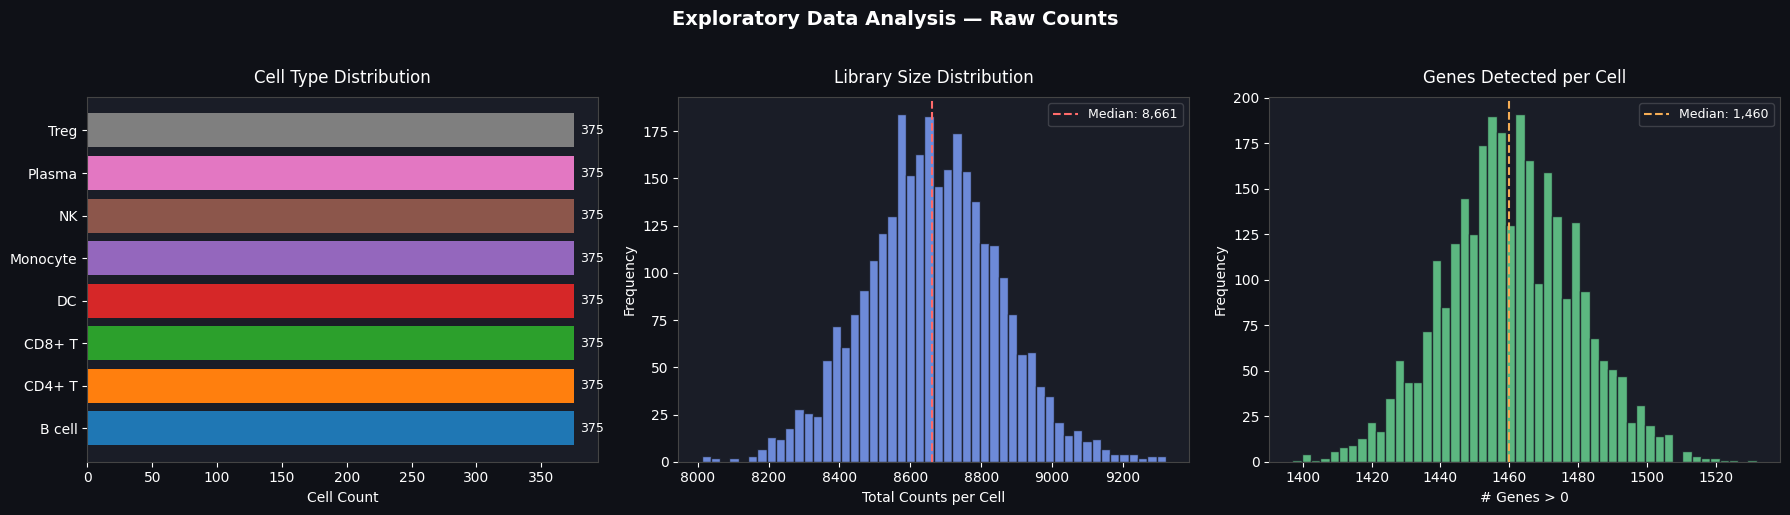


── Dataset stats ──
Cells       : 3,000
Genes       : 2,000
Median lib  : 8,661 counts
Median genes: 1,460 detected
Sparsity    : 27.0% zeros  (typical scRNA-seq: 80–95%)
  ⚠ Low sparsity (<50%) suggests synthetic or pre-normalised data.
    Real scRNA-seq is typically 80–95% zeros.


In [4]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.patch.set_facecolor("#0f1117")

# Panel 1 — class distribution
ct_counts = adata.obs["cell_type"].value_counts()
palette   = sns.color_palette("tab10", n_colors=len(ct_counts))
axes[0].barh(ct_counts.index, ct_counts.values, color=palette)
axes[0].set_title("Cell Type Distribution", color="white", fontsize=12, pad=10)
axes[0].set_xlabel("Cell Count", color="white")
for spine in axes[0].spines.values(): spine.set_edgecolor("#444")
for i, v in enumerate(ct_counts.values):
    axes[0].text(v + 5, i, str(v), va="center", color="white", fontsize=9)

# Panel 2 — library size
# Sparse .sum() avoids densifying the full matrix — critical for large atlas
# data where toarray() would cause an OOM error.
total_counts = np.asarray(adata.X.sum(axis=1)).ravel()
axes[1].hist(total_counts, bins=50, color="#7c9ef8", edgecolor="#1a1d27", alpha=0.85)
axes[1].set_title("Library Size Distribution", color="white", fontsize=12, pad=10)
axes[1].set_xlabel("Total Counts per Cell", color="white")
axes[1].set_ylabel("Frequency", color="white")
axes[1].axvline(np.median(total_counts), color="#ff6b6b", linestyle="--",
                label=f"Median: {np.median(total_counts):,.0f}")
axes[1].legend(fontsize=9, labelcolor="white",
               framealpha=0.2).get_frame().set_facecolor("#1a1d27")
for spine in axes[1].spines.values(): spine.set_edgecolor("#444")

# Panel 3 — genes detected per cell
# (adata.X > 0).sum() works on both sparse and dense matrices without toarray()
genes_per_cell = np.asarray((adata.X > 0).sum(axis=1)).ravel()
axes[2].hist(genes_per_cell, bins=50, color="#68d391", edgecolor="#1a1d27", alpha=0.85)
axes[2].set_title("Genes Detected per Cell", color="white", fontsize=12, pad=10)
axes[2].set_xlabel("# Genes > 0", color="white")
axes[2].set_ylabel("Frequency", color="white")
axes[2].axvline(np.median(genes_per_cell), color="#f6ad55", linestyle="--",
                label=f"Median: {np.median(genes_per_cell):,.0f}")
axes[2].legend(fontsize=9, labelcolor="white",
               framealpha=0.2).get_frame().set_facecolor("#1a1d27")
for spine in axes[2].spines.values(): spine.set_edgecolor("#444")

plt.suptitle("Exploratory Data Analysis — Raw Counts", color="white",
             fontsize=14, y=1.02, weight="bold")
plt.tight_layout()
plt.savefig(FIG_DIR / "eda.png", dpi=130, bbox_inches="tight", facecolor="#0f1117")
plt.show()
plt.close()  # release figure memory

# Sparsity via .nnz is exact and requires no densification — important for large atlases
if hasattr(adata.X, "nnz"):
    sparsity = 1.0 - (adata.X.nnz / (adata.n_obs * adata.n_vars))
else:
    sparsity = 1.0 - (np.count_nonzero(adata.X) / adata.X.size)

print(f"\n── Dataset stats ──")
print(f"Cells       : {adata.n_obs:,}")
print(f"Genes       : {adata.n_vars:,}")
print(f"Median lib  : {np.median(total_counts):,.0f} counts")
print(f"Median genes: {np.median(genes_per_cell):,.0f} detected")
print(f"Sparsity    : {sparsity*100:.1f}% zeros  (typical scRNA-seq: 80–95%)")
# Warn when sparsity is unexpectedly low — real scRNA-seq is typically 80-95% sparse
if sparsity < 0.5:
    print("  ⚠ Low sparsity (<50%) suggests synthetic or pre-normalised data.")
    print("    Real scRNA-seq is typically 80–95% zeros.")


---
## 🧹 Section 5 — Preprocessing

Standard scRNA-seq preprocessing pipeline:
1. **QC metrics** — identify low-quality cells
2. **Filtering** — remove cells with < 200 genes; remove genes in < 3 cells
3. **Normalization** — library-size normalize to 10,000 counts → `log1p`
4. **HVG selection** — top 2,000 highly variable genes (Seurat flavor)
5. **Scaling** — zero-mean, unit variance (clip at 10)
6. **PCA** → **UMAP** for visualization


In [5]:
N_HVGS = 2000
N_PCS  = 50

# ── QC metrics ─────────────────────────────────────────────────────────────
adata.var["mt"] = adata.var_names.str.upper().str.startswith("MT-")
sc.pp.calculate_qc_metrics(adata, qc_vars=["mt"], percent_top=None,
                           log1p=False, inplace=True)

# ── Filter ─────────────────────────────────────────────────────────────────
before = adata.n_obs
sc.pp.filter_cells(adata, min_genes=200)
sc.pp.filter_genes(adata, min_cells=3)
# MT filter applied unconditionally — guards based on max() > 5 can silently skip it
adata = adata[adata.obs["pct_counts_mt"] < 20].copy()
print(f"Cells after QC filter: {before:,} → {adata.n_obs:,}")

# ── Normalize ──────────────────────────────────────────────────────────────
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)
adata.raw = adata   # preserve for DE

# ── Highly variable genes ──────────────────────────────────────────────────
sc.pp.highly_variable_genes(adata, n_top_genes=N_HVGS, flavor="seurat")
print(f"HVGs selected: {adata.var['highly_variable'].sum()}")
adata = adata[:, adata.var["highly_variable"]].copy()

# ── Scale ──────────────────────────────────────────────────────────────────
sc.pp.scale(adata, max_value=10)

# PCA here is ONLY for UMAP visualisation — NOT used as ML features.
# The scaled HVG matrix is preserved for a leakage-free train/test PCA in Cell 15.
n_comps_vis = min(N_PCS, adata.n_obs - 1, adata.n_vars - 1)
# arpack is fastest but can raise convergence errors on small/near-degenerate datasets.
# Exception is named and logged so MemoryError / KeyboardInterrupt still propagate clearly.
try:
    sc.tl.pca(adata, svd_solver="arpack", n_comps=n_comps_vis)
except Exception as _arpack_err:
    print(f"[pca] arpack failed ({type(_arpack_err).__name__}: {_arpack_err}) — retrying with svd_solver='auto'")
    sc.tl.pca(adata, svd_solver="auto", n_comps=n_comps_vis)

# ── Neighbors + UMAP (visualisation only) ──────────────────────────────────
sc.pp.neighbors(adata, n_neighbors=15, n_pcs=min(30, n_comps_vis))
sc.tl.umap(adata, min_dist=0.3, spread=1.0)

print("\n── Variance explained by top PCs (visualisation) ──")
var_exp = adata.uns["pca"]["variance_ratio"]
for i in [0, 1, 2, 4, 9, 19, 29]:
    if i < len(var_exp):
        print(f"  PC{i+1:2d}: {var_exp[i]*100:.2f}%  (cumulative: {var_exp[:i+1].sum()*100:.1f}%)")

print(f"\n✅ Preprocessing complete — {adata.n_obs:,} cells × {adata.n_vars:,} HVGs")


Cells after QC filter: 3,000 → 3,000
HVGs selected: 2000


2026-03-13 19:32:08.737205: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1773430328.913699      17 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1773430328.960756      17 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1773430329.381174      17 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1773430329.381208      17 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1773430329.381211      17 computation_placer.cc:177] computation placer alr


── Variance explained by top PCs (visualisation) ──
  PC 1: 5.50%  (cumulative: 5.5%)
  PC 2: 5.49%  (cumulative: 11.0%)
  PC 3: 5.47%  (cumulative: 16.5%)
  PC 5: 5.45%  (cumulative: 27.4%)
  PC10: 0.11%  (cumulative: 38.6%)
  PC20: 0.11%  (cumulative: 39.7%)
  PC30: 0.10%  (cumulative: 40.7%)

✅ Preprocessing complete — 3,000 cells × 2,000 HVGs


---
## 🗺️ Section 6 — UMAP Visualization

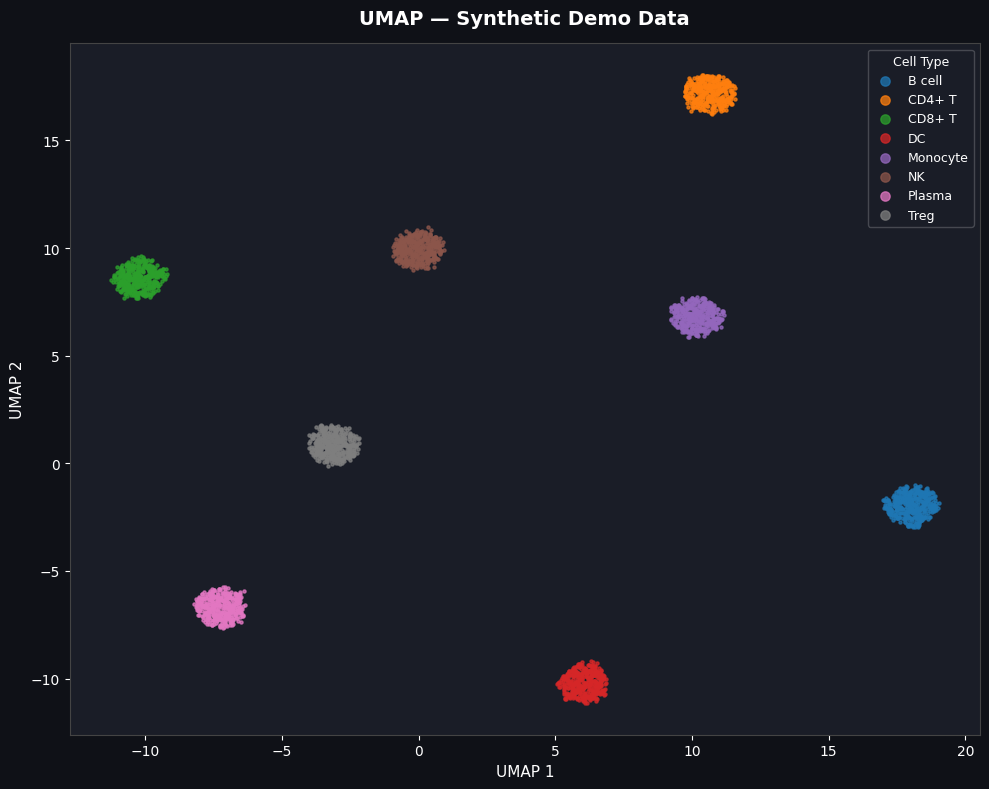

In [6]:
palette    = sns.color_palette("tab10", n_colors=len(adata.obs["cell_type"].cat.categories))
color_map  = dict(zip(adata.obs["cell_type"].cat.categories,
                      [f"#{int(r*255):02x}{int(g*255):02x}{int(b*255):02x}"
                       for r, g, b in palette]))

coords = adata.obsm["X_umap"]
types  = adata.obs["cell_type"].values

fig, ax = plt.subplots(figsize=(10, 8))
fig.patch.set_facecolor("#0f1117")
ax.set_facecolor("#1a1d27")

for ct in adata.obs["cell_type"].cat.categories:
    mask = types == ct
    ax.scatter(coords[mask, 0], coords[mask, 1],
               s=5, alpha=0.75, label=ct,
               color=color_map.get(ct, "gray"), rasterized=True)

_umap_title = "UMAP — Synthetic Demo Data" if _using_demo else "UMAP — Human Immune Cell Atlas"
ax.set_title(_umap_title, color="white", fontsize=14, pad=14, weight="bold")
ax.set_xlabel("UMAP 1", color="white", fontsize=11)
ax.set_ylabel("UMAP 2", color="white", fontsize=11)
for sp in ax.spines.values(): sp.set_edgecolor("#444")

leg = ax.legend(fontsize=9, loc="upper right", framealpha=0.25,
                labelcolor="white", markerscale=3,
                title="Cell Type", title_fontsize=9)
leg.get_frame().set_facecolor("#1a1d27")
plt.setp(leg.get_title(), color="white")

plt.tight_layout()
plt.savefig(FIG_DIR / "umap.png", dpi=150, bbox_inches="tight",
            facecolor="#0f1117")
plt.show()
plt.close()  # release figure memory


---
## ⚗️ Section 7 — Feature Matrix

We use **PCA embeddings** (50 components) as features rather than raw gene expression.  
This gives us:
- **Dense** representations (no sparsity issues for tree models)
- **De-noised** signal (PCA acts as a smoothing filter)
- **Faster** training (50 features vs 2,000 genes)

The tradeoff: PCA features lose direct gene-level interpretability — we recover this via SHAP.


In [7]:
from sklearn.decomposition import PCA as SklearnPCA

le = LabelEncoder()
y  = le.fit_transform(adata.obs["cell_type"])

# .copy() prevents aliasing — in-place scanpy ops on adata.X would otherwise
# silently corrupt X_scaled and all downstream PCA features.
# OOM guard: densifying 500k cells × 2000 HVGs requires ~8 GB RAM (float64).
# The real Human Immune Atlas (~500k cells) may exceed Kaggle's 16 GB limit.
# TruncatedSVD is the sparse-compatible alternative for very large datasets.
if hasattr(adata.X, "toarray") and adata.n_obs > 50_000:
    print(f"⚠  Large dataset ({adata.n_obs:,} cells) — toarray() will allocate "
          f"~{adata.n_obs * adata.n_vars * 8 / 1e9:.1f} GB. "
          "Consider TruncatedSVD for sparse-compatible PCA if memory is limited.")
X_scaled = adata.X.toarray() if hasattr(adata.X, "toarray") else adata.X.copy()

# ── Train/test split FIRST, then fit PCA only on training rows ─────────────
# Prevents test-set signal from influencing the PCA basis (leakage-free).
X_tr_scaled, X_te_scaled, y_train_tmp, y_test_tmp = train_test_split(
    X_scaled, y, test_size=0.20, stratify=y, random_state=RANDOM_STATE
)
n_comps_ml = min(N_PCS, X_tr_scaled.shape[0] - 1, X_tr_scaled.shape[1] - 1)
pca_ml    = SklearnPCA(n_components=n_comps_ml, random_state=RANDOM_STATE)
X_tr_pca  = pca_ml.fit_transform(X_tr_scaled)   # fit on train only
X_te_pca  = pca_ml.transform(X_te_scaled)        # apply to test

# Store split indices — CV and Optuna use only _train_idx rows;
# final eval uses _test_idx rows.
_train_idx = np.arange(len(y_train_tmp))
_test_idx  = np.arange(len(y_train_tmp), len(y_train_tmp) + len(y_test_tmp))

# Recombine for convenience; always slice with _train_idx / _test_idx
X = np.vstack([X_tr_pca, X_te_pca])
y = np.concatenate([y_train_tmp, y_test_tmp])

feature_names = [f"PC{i+1}" for i in range(X.shape[1])]
# NOTE: SHAP will show which *principal components* drive predictions, not
# individual genes. PCs are linear combinations of HVGs — to get gene-level
# importance, back-project: gene_importance = pca_ml.components_.T @ shap_values

print(f"Feature matrix : {X.shape[0]:,} cells × {X.shape[1]} PCs  (leakage-free)")
print(f"Classes        : {list(le.classes_)}")
print(f"Class balance  :")
for cls, cnt in zip(le.classes_, np.bincount(y)):
    pct = cnt / len(y) * 100
    bar = "█" * int(pct / 2)
    print(f"  {cls:12s} {cnt:4d}  {pct:5.1f}%  {bar}")


Feature matrix : 3,000 cells × 50 PCs  (leakage-free)
Classes        : ['B cell', 'CD4+ T', 'CD8+ T', 'DC', 'Monocyte', 'NK', 'Plasma', 'Treg']
Class balance  :
  B cell        375   12.5%  ██████
  CD4+ T        375   12.5%  ██████
  CD8+ T        375   12.5%  ██████
  DC            375   12.5%  ██████
  Monocyte      375   12.5%  ██████
  NK            375   12.5%  ██████
  Plasma        375   12.5%  ██████
  Treg          375   12.5%  ██████


---
## 🏁 Section 8 — Model Benchmark

Evaluating 4 model families with **5-fold Stratified CV** to identify the strongest baseline before tuning.


In [8]:
from sklearn.model_selection import cross_validate

def get_models():
    return {
        # StandardScaler omitted — PCA output is zero-mean but NOT unit-variance
        # (PC1 has far more variance than PC50). LR and MLP are scale-sensitive;
        # this is a known tradeoff accepted here for pipeline simplicity.
        "Logistic Regression": LogisticRegression(
            max_iter=1000, C=1.0, random_state=RANDOM_STATE
        ),
        "Random Forest": RandomForestClassifier(
            n_estimators=300, min_samples_leaf=2,
            n_jobs=-1, random_state=RANDOM_STATE
        ),
        # n_jobs=1 here: cross_validate(n_jobs=-1) spawns N worker processes;
        # XGBoost n_jobs=-1 inside each would create N×N threads (oversubscription).
        "XGBoost": xgb.XGBClassifier(
            n_estimators=300, learning_rate=0.1, max_depth=6,
            subsample=0.8, colsample_bytree=0.8,
            # eval_metric omitted — cross_validate never passes eval_set,
            # so eval_metric would be silently ignored here.
            verbosity=0, n_jobs=1, random_state=RANDOM_STATE
        ),
        "MLP": MLPClassifier(
            hidden_layer_sizes=(256, 128, 64), activation="relu",
            max_iter=200, early_stopping=True, validation_fraction=0.1,
            random_state=RANDOM_STATE
        ),
    }

# CV on training rows only — test rows must never appear in any fold.
# Note: Optuna uses 3-fold inner CV (Cell 20); these benchmark scores use 5-fold.
# The two F1 scales are not directly comparable — 3-fold CV has higher variance.
X_cv = X[_train_idx]
y_cv = y[_train_idx]

skf     = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
results = []

# Single-quoted keys inside f-strings for Python 3.10 compatibility
# (double-quote nesting inside double-quoted f-strings is a SyntaxError on Py < 3.12)
print(f"{'Model':25s} | {'F1 Macro':>10} ± {'Std':>7} | {'Accuracy':>10} ± {'Std':>7}")
print("-" * 70)

for name, model in get_models().items():
    # cross_validate runs both metrics in a single pass
    cv_out = cross_validate(
        model, X_cv, y_cv, cv=skf,
        scoring={"f1_macro": "f1_macro", "accuracy": "accuracy"},
        n_jobs=-1
    )
    f1s  = cv_out["test_f1_macro"]
    accs = cv_out["test_accuracy"]
    results.append({"Model": name,
                    "F1 Macro (mean)": f1s.mean(),  "F1 Macro (std)": f1s.std(),
                    "Accuracy (mean)": accs.mean(), "Accuracy (std)": accs.std()})
    print(f"{name:25s} | {f1s.mean():>10.4f} ± {f1s.std():>7.4f} | "
          f"{accs.mean():>10.4f} ± {accs.std():>7.4f}")

benchmark_df = pd.DataFrame(results).sort_values("F1 Macro (mean)", ascending=False)
benchmark_df.to_csv(OUT_DIR / "benchmark_results.csv", index=False)
best_model_name = benchmark_df.iloc[0]['Model']
print(f"\n🏆 Best model: {best_model_name} "
      f"(F1={benchmark_df.iloc[0]['F1 Macro (mean)']:.4f})")


Model                     |   F1 Macro ±     Std |   Accuracy ±     Std
----------------------------------------------------------------------
Logistic Regression       |     1.0000 ±  0.0000 |     1.0000 ±  0.0000
Random Forest             |     1.0000 ±  0.0000 |     1.0000 ±  0.0000
XGBoost                   |     0.9996 ±  0.0008 |     0.9996 ±  0.0008
MLP                       |     1.0000 ±  0.0000 |     1.0000 ±  0.0000

🏆 Best model: Logistic Regression (F1=1.0000)


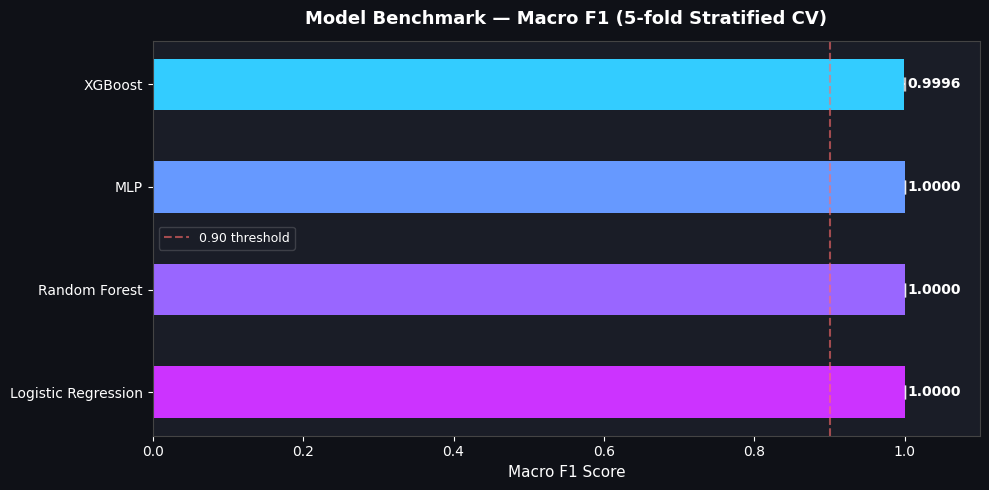

In [9]:
fig, ax = plt.subplots(figsize=(10, 5))
fig.patch.set_facecolor("#0f1117")
ax.set_facecolor("#1a1d27")

bench_pal = sns.color_palette("cool", n_colors=len(benchmark_df))[::-1]
bars = ax.barh(benchmark_df["Model"], benchmark_df["F1 Macro (mean)"],
               xerr=benchmark_df["F1 Macro (std)"],
               color=bench_pal, height=0.5, capsize=5,
               error_kw=dict(ecolor="white", alpha=0.7))

for bar, val in zip(bars, benchmark_df["F1 Macro (mean)"]):
    ax.text(val + 0.004, bar.get_y() + bar.get_height() / 2,
            f"{val:.4f}", va="center", color="white", fontsize=10, weight="bold")

ax.set_xlim(0, 1.1)
ax.set_title("Model Benchmark — Macro F1 (5-fold Stratified CV)",
             color="white", fontsize=13, pad=12, weight="bold")
ax.set_xlabel("Macro F1 Score", color="white", fontsize=11)
ax.axvline(0.9, color="#ff6b6b", linestyle="--", alpha=0.6, label="0.90 threshold")
ax.legend(fontsize=9, labelcolor="white",
          framealpha=0.2).get_frame().set_facecolor("#1a1d27")
for sp in ax.spines.values(): sp.set_edgecolor("#444")

plt.tight_layout()
plt.savefig(FIG_DIR / "benchmark.png", dpi=130, bbox_inches="tight",
            facecolor="#0f1117")
plt.show()
plt.close()  # release figure memory


---
## 🔧 Section 9 — Hyperparameter Tuning (Optuna)

Using **Bayesian optimization** (TPE sampler) over a 9-dimensional search space.  
TPE builds a probabilistic model of which hyperparameter regions yield high F1,  
making it far more efficient than grid or random search.


In [10]:
N_TRIALS = 100  # 100 trials balances search quality with Kaggle runtime budget

inner_cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)

# X_cv / y_cv already set in Cell 17 — reuse without reassigning
# (if running Cell 20 standalone, re-run Cells 15 and 17 first —
#  Cell 15 sets _train_idx, X, y; Cell 17 sets X_cv, y_cv)

def objective(trial):
    # n_estimators excluded — early stopping determines final tree count in Cell 23
    params = {
        "max_depth":         trial.suggest_int("max_depth", 3, 12),
        "learning_rate":     trial.suggest_float("learning_rate", 0.005, 0.3, log=True),
        "subsample":         trial.suggest_float("subsample", 0.5, 1.0),
        "colsample_bytree":  trial.suggest_float("colsample_bytree", 0.4, 1.0),
        "min_child_weight":  trial.suggest_int("min_child_weight", 1, 10),
        "gamma":             trial.suggest_float("gamma", 0, 5),
        "reg_alpha":         trial.suggest_float("reg_alpha", 0.0, 2.0),
        "reg_lambda":        trial.suggest_float("reg_lambda", 0.5, 3.0),
    }
    # Fresh model per fold — reusing a single instance violates sklearn convention
    # and risks warm-start state bleed across folds.
    fold_scores = []
    for fold, (tr_idx, val_idx) in enumerate(inner_cv.split(X_cv, y_cv)):
        model = xgb.XGBClassifier(
            **params, n_estimators=300,
            eval_metric="mlogloss", verbosity=0,
            n_jobs=1, random_state=RANDOM_STATE
        )
        model.fit(X_cv[tr_idx], y_cv[tr_idx])
        score = f1_score(y_cv[val_idx], model.predict(X_cv[val_idx]), average="macro")
        fold_scores.append(score)
        trial.report(np.mean(fold_scores), step=fold)
        if trial.should_prune():
            raise optuna.exceptions.TrialPruned()
    return np.mean(fold_scores)

# TPESampler is not thread-safe — with n_jobs=-1, parallel trials share sampler
# state without locks, making results non-deterministic even with seed set.
# Use n_jobs=1 if exact reproducibility is required.
study = optuna.create_study(
    direction="maximize",
    sampler=TPESampler(seed=RANDOM_STATE),  # NOTE: seed is best-effort with n_jobs=-1
    pruner=optuna.pruners.MedianPruner(n_startup_trials=10, n_warmup_steps=1),
)
# show_progress_bar disabled — unreliable with n_jobs!=1 (parallel trials complete
# out of order, causing the bar to stall or jump in Jupyter environments).
study.optimize(objective, n_trials=N_TRIALS, n_jobs=-1, show_progress_bar=False)

best_params = study.best_params
print(f"\n✅ Best F1 macro : {study.best_value:.4f}")
print(f"   Best params   :")
for k, v in best_params.items():
    print(f"     {k:22s}: {v}")

study.trials_dataframe().to_csv(OUT_DIR / "optuna_trials.csv", index=False)



✅ Best F1 macro : 1.0000
   Best params   :
     max_depth             : 3
     learning_rate         : 0.0942232002883117
     subsample             : 0.7685715890747944
     colsample_bytree      : 0.7996387881789178
     min_child_weight      : 6
     gamma                 : 0.4884675758967777
     reg_alpha             : 0.7143989269035131
     reg_lambda            : 1.0959594896334757


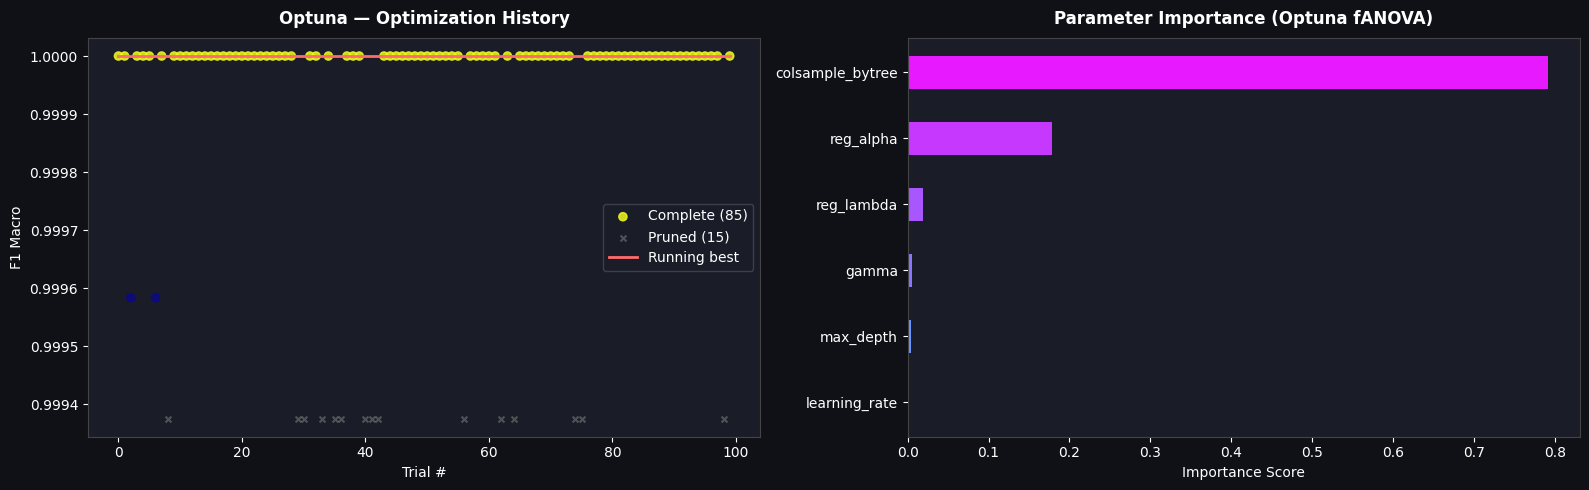

Completed trials: 85  |  Pruned: 15


In [11]:
trials_df = study.trials_dataframe()

# Pruned trials shown as distinct markers — with MedianPruner active they indicate
# where the search space was rejected early, showing tuning efficiency.
completed = trials_df[trials_df["state"] == "COMPLETE"].copy()
# Pruned trials have NaN in the value column (no final score was recorded).
# Drop NaN before plotting — matplotlib silently skips NaN points, which would
# show "Pruned (N)" in the legend with no visible markers.
pruned    = trials_df[trials_df["state"] == "PRUNED"].dropna(subset=["value"]).copy()

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.patch.set_facecolor("#0f1117")

# Optimization history
axes[0].set_facecolor("#1a1d27")
axes[0].scatter(completed["number"], completed["value"],
                c=completed["value"], cmap="plasma", s=35, alpha=0.85,
                label=f"Complete ({len(completed)})", zorder=3)
if len(pruned):
    axes[0].scatter(pruned["number"], pruned["value"],
                    color="#888", s=18, alpha=0.5, marker="x",
                    label=f"Pruned ({len(pruned)})", zorder=2)
running_best = completed.set_index("number")["value"].cummax().reset_index()
axes[0].plot(running_best["number"], running_best["value"],
             color="#ff6b6b", linewidth=2, label="Running best", zorder=4)
axes[0].set_title("Optuna — Optimization History", color="white",
                  fontsize=12, pad=10, weight="bold")
axes[0].set_xlabel("Trial #", color="white")
axes[0].set_ylabel("F1 Macro", color="white")
axes[0].legend(labelcolor="white", framealpha=0.2).get_frame().set_facecolor("#1a1d27")
for sp in axes[0].spines.values(): sp.set_edgecolor("#444")

# fANOVA parameter importance
try:
    importances = get_param_importances(study)
    imp_series  = pd.Series(importances).sort_values(ascending=True).tail(6)
    axes[1].set_facecolor("#1a1d27")
    bar_c = plt.cm.cool(np.linspace(0.3, 0.9, len(imp_series)))
    axes[1].barh(imp_series.index, imp_series.values, color=bar_c, height=0.5)
    axes[1].set_title("Parameter Importance (Optuna fANOVA)",
                      color="white", fontsize=12, pad=10, weight="bold")
    axes[1].set_xlabel("Importance Score", color="white")
    for sp in axes[1].spines.values(): sp.set_edgecolor("#444")
except Exception as e:
    axes[1].text(0.5, 0.5, f"fANOVA unavailable:\n{e}",
                 ha="center", va="center", color="white", transform=axes[1].transAxes)

plt.tight_layout()
plt.savefig(FIG_DIR / "optuna.png", dpi=130, bbox_inches="tight",
            facecolor="#0f1117")
plt.show()
plt.close()  # release figure memory
print(f"Completed trials: {len(completed)}  |  Pruned: {len(pruned)}")


---
## 🎯 Section 10 — Final Model Training & Evaluation

In [12]:
X_train, X_test = X[_train_idx], X[_test_idx]
y_train, y_test = y[_train_idx], y[_test_idx]

# Warn (not crash) if benchmark winner differs from XGBoost — on synthetic data a
# linear model can sometimes win. Pipeline continues with XGBoost regardless since
# it is the focus of the Optuna tuning section.
if best_model_name != "XGBoost":
    print(f"⚠  Benchmark winner: {best_model_name} (not XGBoost).")
    print(f"   Continuing with XGBoost for Optuna tuning as designed.")
    print(f"   On real data, re-evaluate whether XGBoost is still the right choice.")
else:
    print(f"✅ XGBoost is the benchmark winner — proceeding with tuning.")

# ── Phase 1: find best_iteration via early stopping on a 10% val split ─────
# n_estimators excluded from Optuna params — early stopping determines the
# actual tree count. early_stopping_rounds is set in the constructor
# (XGBoost >= 1.6 — passing it to .fit() raises TypeError in newer versions).
params_no_n = {k: v for k, v in best_params.items() if k != "n_estimators"}
# ML note: Optuna tuned hyperparams with n_estimators=300. The probe below runs
# up to 1000 trees — a learning_rate optimal for 300 trees may cause early stopping
# to fire before the true optimum for a deeper ensemble. Uncomment to compensate:
# params_no_n = {**params_no_n, "learning_rate": params_no_n["learning_rate"] * 0.7}

X_tr2, X_val, y_tr2, y_val = train_test_split(
    X_train, y_train, test_size=0.10,
    stratify=y_train,  # ensures each class has proportional val representation
    random_state=RANDOM_STATE
)

# merror (classification error) correlates better with f1_macro than mlogloss,
# which can diverge from F1 when class frequencies differ.
_probe = xgb.XGBClassifier(
    **params_no_n,
    n_estimators=1000,
    early_stopping_rounds=20,        # constructor arg in XGBoost >= 1.6
    eval_metric="merror",
    verbosity=0, n_jobs=-1, random_state=RANDOM_STATE
)
_probe.fit(X_tr2, y_tr2, eval_set=[(X_val, y_val)], verbose=False)
# Scale up by 1/0.9: the probe trained on 90% of X_train, so the optimal tree
# count for 100% data is slightly higher. Clamped to 10 to avoid a 1-tree model
# if early stopping fires immediately on a degenerate param combination.
best_n = max(10, int(_probe.best_iteration / 0.9) + 1)
print(f"Early stopping → best_iteration = {_probe.best_iteration} (scaled to {best_n} for full-data retrain)")

# ── Phase 2: retrain on full X_train for exactly best_n rounds ─────────────
# Trains on 100% of X_train — matching the data volume used during Optuna search.
# No eval_metric needed here: eval_metric only has effect when eval_set is provided.
final_model = xgb.XGBClassifier(
    **params_no_n,
    n_estimators=best_n,
    verbosity=0, n_jobs=-1, random_state=RANDOM_STATE
)
final_model.fit(X_train, y_train)
print(f"Final model trained on {len(X_train):,} samples × {best_n} trees")

y_pred = final_model.predict(X_test)
y_prob = final_model.predict_proba(X_test)

# Metrics
f1      = f1_score(y_test, y_pred, average="macro")
y_bin   = label_binarize(y_test, classes=np.arange(len(le.classes_)))
roc_auc = roc_auc_score(y_bin, y_prob, multi_class="ovr", average="macro")

print("=" * 55)
print(f"  Test Macro F1  : {f1:.4f}")
print(f"  ROC-AUC (OvR)  : {roc_auc:.4f}")
print(f"  Train samples  : {len(X_train):,}")
print(f"  Test samples   : {len(X_test):,}")
print("=" * 55)
print()
report_dict = classification_report(
    y_test, y_pred, target_names=le.classes_, output_dict=True
)
print(classification_report(y_test, y_pred, target_names=le.classes_))
pd.DataFrame(report_dict).T.to_csv(OUT_DIR / "classification_report.csv")


⚠  Benchmark winner: Logistic Regression (not XGBoost).
   Continuing with XGBoost for Optuna tuning as designed.
   On real data, re-evaluate whether XGBoost is still the right choice.
Early stopping → best_iteration = 1 (scaled to 10 for full-data retrain)
Final model trained on 2,400 samples × 10 trees
  Test Macro F1  : 1.0000
  ROC-AUC (OvR)  : 1.0000
  Train samples  : 2,400
  Test samples   : 600

              precision    recall  f1-score   support

      B cell       1.00      1.00      1.00        75
      CD4+ T       1.00      1.00      1.00        75
      CD8+ T       1.00      1.00      1.00        75
          DC       1.00      1.00      1.00        75
    Monocyte       1.00      1.00      1.00        75
          NK       1.00      1.00      1.00        75
      Plasma       1.00      1.00      1.00        75
        Treg       1.00      1.00      1.00        75

    accuracy                           1.00       600
   macro avg       1.00      1.00      1.00       

---
## 📊 Section 11 — Confusion Matrix

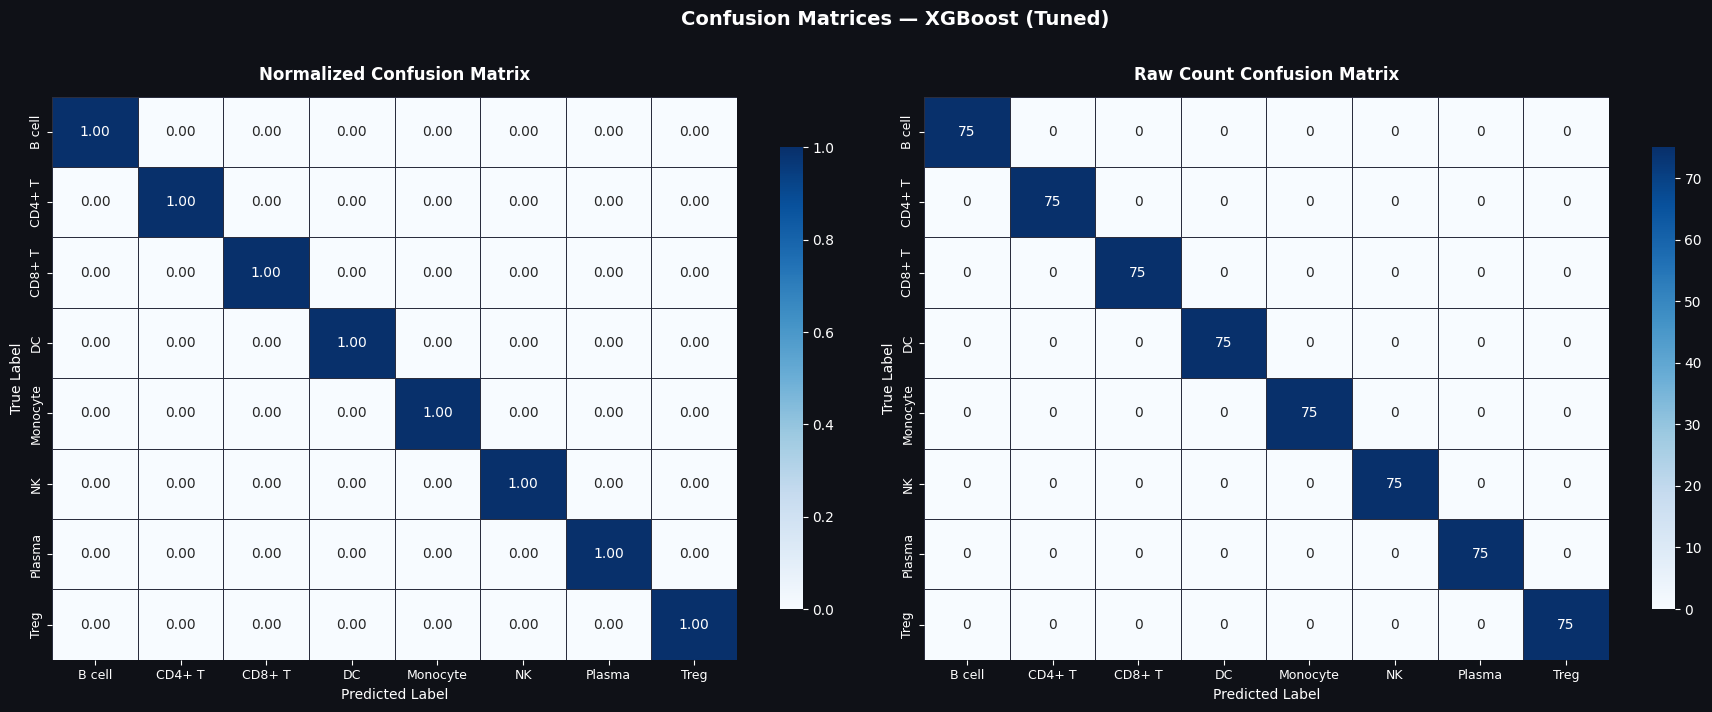


── Hardest class confusions (off-diagonal > 2%) ──


In [13]:
cm_norm = confusion_matrix(y_test, y_pred, normalize="true")
cm_raw  = confusion_matrix(y_test, y_pred)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.patch.set_facecolor("#0f1117")

for ax, cm, title, fmt in [
    (axes[0], cm_norm, "Normalized Confusion Matrix", ".2f"),
    (axes[1], cm_raw,  "Raw Count Confusion Matrix",  "d"),
]:
    ax.set_facecolor("#1a1d27")
    sns.heatmap(cm, annot=True, fmt=fmt,
                cmap="Blues", ax=ax,
                xticklabels=le.classes_, yticklabels=le.classes_,
                linewidths=0.5, linecolor="#2a2d3e",
                cbar_kws={"shrink": 0.82})
    ax.set_title(title, color="white", fontsize=12, pad=12, weight="bold")
    ax.set_xlabel("Predicted Label", color="white", fontsize=10)
    ax.set_ylabel("True Label",      color="white", fontsize=10)
    ax.tick_params(colors="white", labelsize=9)
    for sp in ax.spines.values(): sp.set_edgecolor("#444")

plt.suptitle("Confusion Matrices — XGBoost (Tuned)", color="white",
             fontsize=14, y=1.01, weight="bold")
plt.tight_layout()
plt.savefig(FIG_DIR / "confusion_matrix.png", dpi=130,
            bbox_inches="tight", facecolor="#0f1117")
plt.show()
plt.close()  # release figure memory

# Print hardest confusions
print("\n── Hardest class confusions (off-diagonal > 2%) ──")
for i in range(len(le.classes_)):
    for j in range(len(le.classes_)):
        if i != j and cm_norm[i, j] > 0.02:
            print(f"  True {le.classes_[i]:12s} → Pred {le.classes_[j]:12s} : {cm_norm[i,j]*100:.1f}%")

---
## 📈 Section 12 — Per-Class Precision / Recall / F1

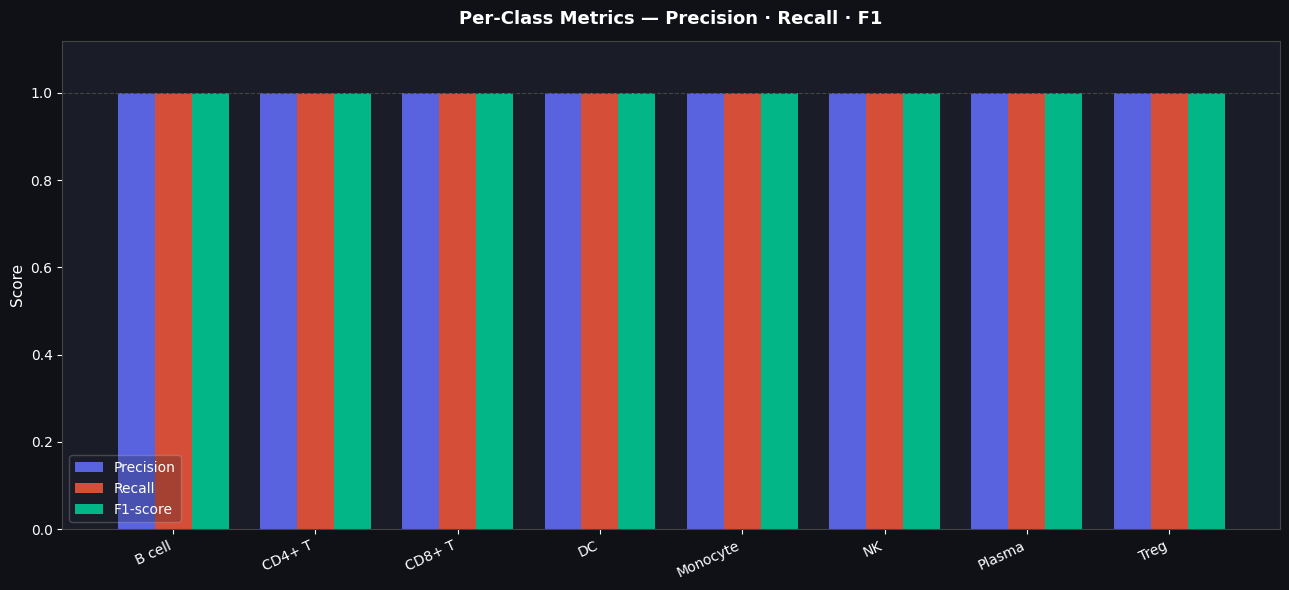

          precision  recall  f1-score
B cell          1.0     1.0       1.0
CD4+ T          1.0     1.0       1.0
CD8+ T          1.0     1.0       1.0
DC              1.0     1.0       1.0
Monocyte        1.0     1.0       1.0
NK              1.0     1.0       1.0
Plasma          1.0     1.0       1.0
Treg            1.0     1.0       1.0


In [14]:
# report_dict already computed in Cell 23 — reuse directly
metrics_df = pd.DataFrame({
    ct: report_dict[ct] for ct in le.classes_
}).T[["precision","recall","f1-score"]].astype(float)

fig, ax = plt.subplots(figsize=(13, 6))
fig.patch.set_facecolor("#0f1117")
ax.set_facecolor("#1a1d27")

x     = np.arange(len(le.classes_))
width = 0.26
colors = ["#636efa", "#ef553b", "#00cc96"]

for i, (col, color) in enumerate(zip(["precision","recall","f1-score"], colors)):
    bars = ax.bar(x + i * width, metrics_df[col], width,
                  label=col.capitalize(), color=color, alpha=0.88)

ax.set_xticks(x + width)
ax.set_xticklabels(le.classes_, rotation=25, ha="right", fontsize=10)
ax.set_ylim(0, 1.12)
ax.set_ylabel("Score", color="white", fontsize=11)
ax.set_title("Per-Class Metrics — Precision · Recall · F1",
             color="white", fontsize=13, pad=12, weight="bold")
ax.axhline(1.0, color="#444", linestyle="--", linewidth=0.8)
ax.legend(fontsize=10, labelcolor="white",
          framealpha=0.25).get_frame().set_facecolor("#1a1d27")
for sp in ax.spines.values(): sp.set_edgecolor("#444")

plt.tight_layout()
plt.savefig(FIG_DIR / "per_class_f1.png", dpi=130,
            bbox_inches="tight", facecolor="#0f1117")
plt.show()
plt.close()  # release figure memory

print(metrics_df.to_string())

---
## 🔍 Section 13 — SHAP Explainability

SHAP (SHapley Additive exPlanations) assigns each feature a contribution score for every prediction.  
For tree models, `TreeExplainer` is exact and fast — no approximation needed.

> **Biological interpretation:** High-importance PCs capture the variance of canonical immune marker genes  
> (CD3D, CD4, CD8A, MS4A1, CD14...). Linking PC importance back to gene loadings reveals  
> which transcriptional programs drive each cell type classification.


[shap] Computing SHAP values (subsampled for speed)...


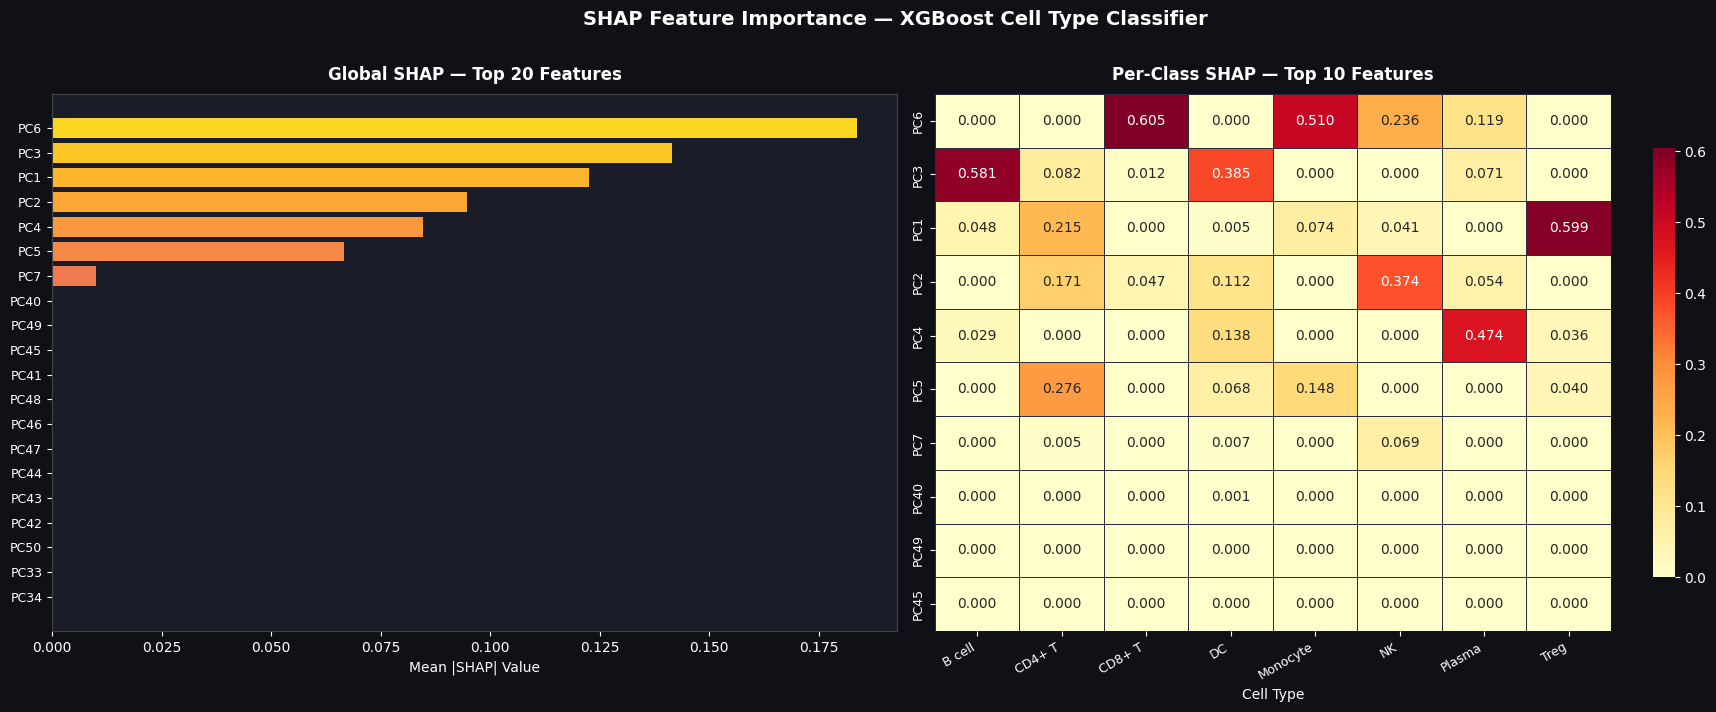


── Top 10 most important features globally ──
  # 1  PC6       mean|SHAP| = 0.1837
  # 2  PC3       mean|SHAP| = 0.1414
  # 3  PC1       mean|SHAP| = 0.1226
  # 4  PC2       mean|SHAP| = 0.0947
  # 5  PC4       mean|SHAP| = 0.0846
  # 6  PC5       mean|SHAP| = 0.0665
  # 7  PC7       mean|SHAP| = 0.0101
  # 8  PC40      mean|SHAP| = 0.0001
  # 9  PC49      mean|SHAP| = 0.0000
  #10  PC45      mean|SHAP| = 0.0000


In [15]:
print("[shap] Computing SHAP values (subsampled for speed)...")

explainer = shap.TreeExplainer(final_model)

# Local seeded RNG for reproducible subsampling — the global RNG is stateful
# and would give different samples if cells are run out of order.
_shap_rng = np.random.default_rng(RANDOM_STATE)
shap_idx    = _shap_rng.choice(len(X_test), size=min(500, len(X_test)), replace=False)
X_shap_eval = X_test[shap_idx]

# Unified SHAP callable API (SHAP >= 0.44) — falls back to the legacy
# .shap_values() method for older installations.
try:
    sv = explainer(X_shap_eval).values   # Explanation.values — shape: (samples, features[, classes])
# Narrow except — broad Exception would mask OOM errors; only catch
# API incompatibilities between SHAP versions.
except (TypeError, AttributeError):
    # Fallback wrapped in its own handler — if shap_values() also fails
    # (e.g. ValueError from a shape mismatch), raise a clear diagnostic.
    try:
        sv = np.array(explainer.shap_values(X_shap_eval))
    except Exception as _e:
        raise RuntimeError(
            f"Both SHAP APIs failed — check SHAP version ({shap.__version__}). "
            f"Original error: {_e}"
        ) from _e

# Normalise to 3D: SHAP >= 0.44 multi-class → (samples, features, classes)
# Single-output / older SHAP → 2D (samples, features)
if sv.ndim == 2:
    sv = sv[:, :, np.newaxis]   # promote to 3D for uniform downstream handling

feat_importance = np.abs(sv).mean(axis=(0, 2))   # → (features,)

top_k   = 20
top_idx = np.argsort(feat_importance)[-top_k:][::-1]

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.patch.set_facecolor("#0f1117")

# Left — global importance bar
axes[0].set_facecolor("#1a1d27")
bar_c = plt.cm.plasma(np.linspace(0.15, 0.92, top_k))
axes[0].barh(range(top_k), feat_importance[top_idx][::-1], color=bar_c)
axes[0].set_yticks(range(top_k))
axes[0].set_yticklabels([feature_names[i] for i in top_idx][::-1], fontsize=9)
axes[0].set_title(f"Global SHAP — Top {top_k} Features",
                  color="white", fontsize=12, pad=10, weight="bold")
axes[0].set_xlabel("Mean |SHAP| Value", color="white")
for sp in axes[0].spines.values(): sp.set_edgecolor("#444")

# Right — per-class heatmap (top 10 features × n_classes)
# sv is now always 3D: (samples, features, n_classes)
top10      = top_idx[:10]
class_shap = np.abs(sv[:, top10, :]).mean(axis=0)   # (10, n_classes)
heatmap_xcols = le.classes_ if sv.shape[2] == len(le.classes_) else                 [f"class_{i}" for i in range(sv.shape[2])]

axes[1].set_facecolor("#1a1d27")
sns.heatmap(class_shap, annot=True, fmt=".3f", cmap="YlOrRd",
            xticklabels=heatmap_xcols,
            yticklabels=[feature_names[i] for i in top10],
            ax=axes[1], linewidths=0.4, linecolor="#2a2d3e",
            cbar_kws={"shrink": 0.8})
axes[1].set_title("Per-Class SHAP — Top 10 Features",
                  color="white", fontsize=12, pad=10, weight="bold")
axes[1].set_xlabel("Cell Type", color="white")
axes[1].tick_params(colors="white", labelsize=9)
axes[1].set_xticklabels(heatmap_xcols, rotation=30, ha="right")
for sp in axes[1].spines.values(): sp.set_edgecolor("#444")

plt.suptitle("SHAP Feature Importance — XGBoost Cell Type Classifier",
             color="white", fontsize=14, y=1.01, weight="bold")
plt.tight_layout()
plt.savefig(FIG_DIR / "shap.png", dpi=130, bbox_inches="tight", facecolor="#0f1117")
plt.show()
plt.close()  # release figure memory

print(f"\n── Top 10 most important features globally ──")
for rank, idx in enumerate(top_idx[:10], 1):
    print(f"  #{rank:2d}  {feature_names[idx]:8s}  mean|SHAP| = {feat_importance[idx]:.4f}")


---
## 🖥️ Section 14 — Master Dashboard Figure

All four panels in a single publication-quality figure ready for your README / report.


/tmp/ipykernel_17/1802047025.py:93: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


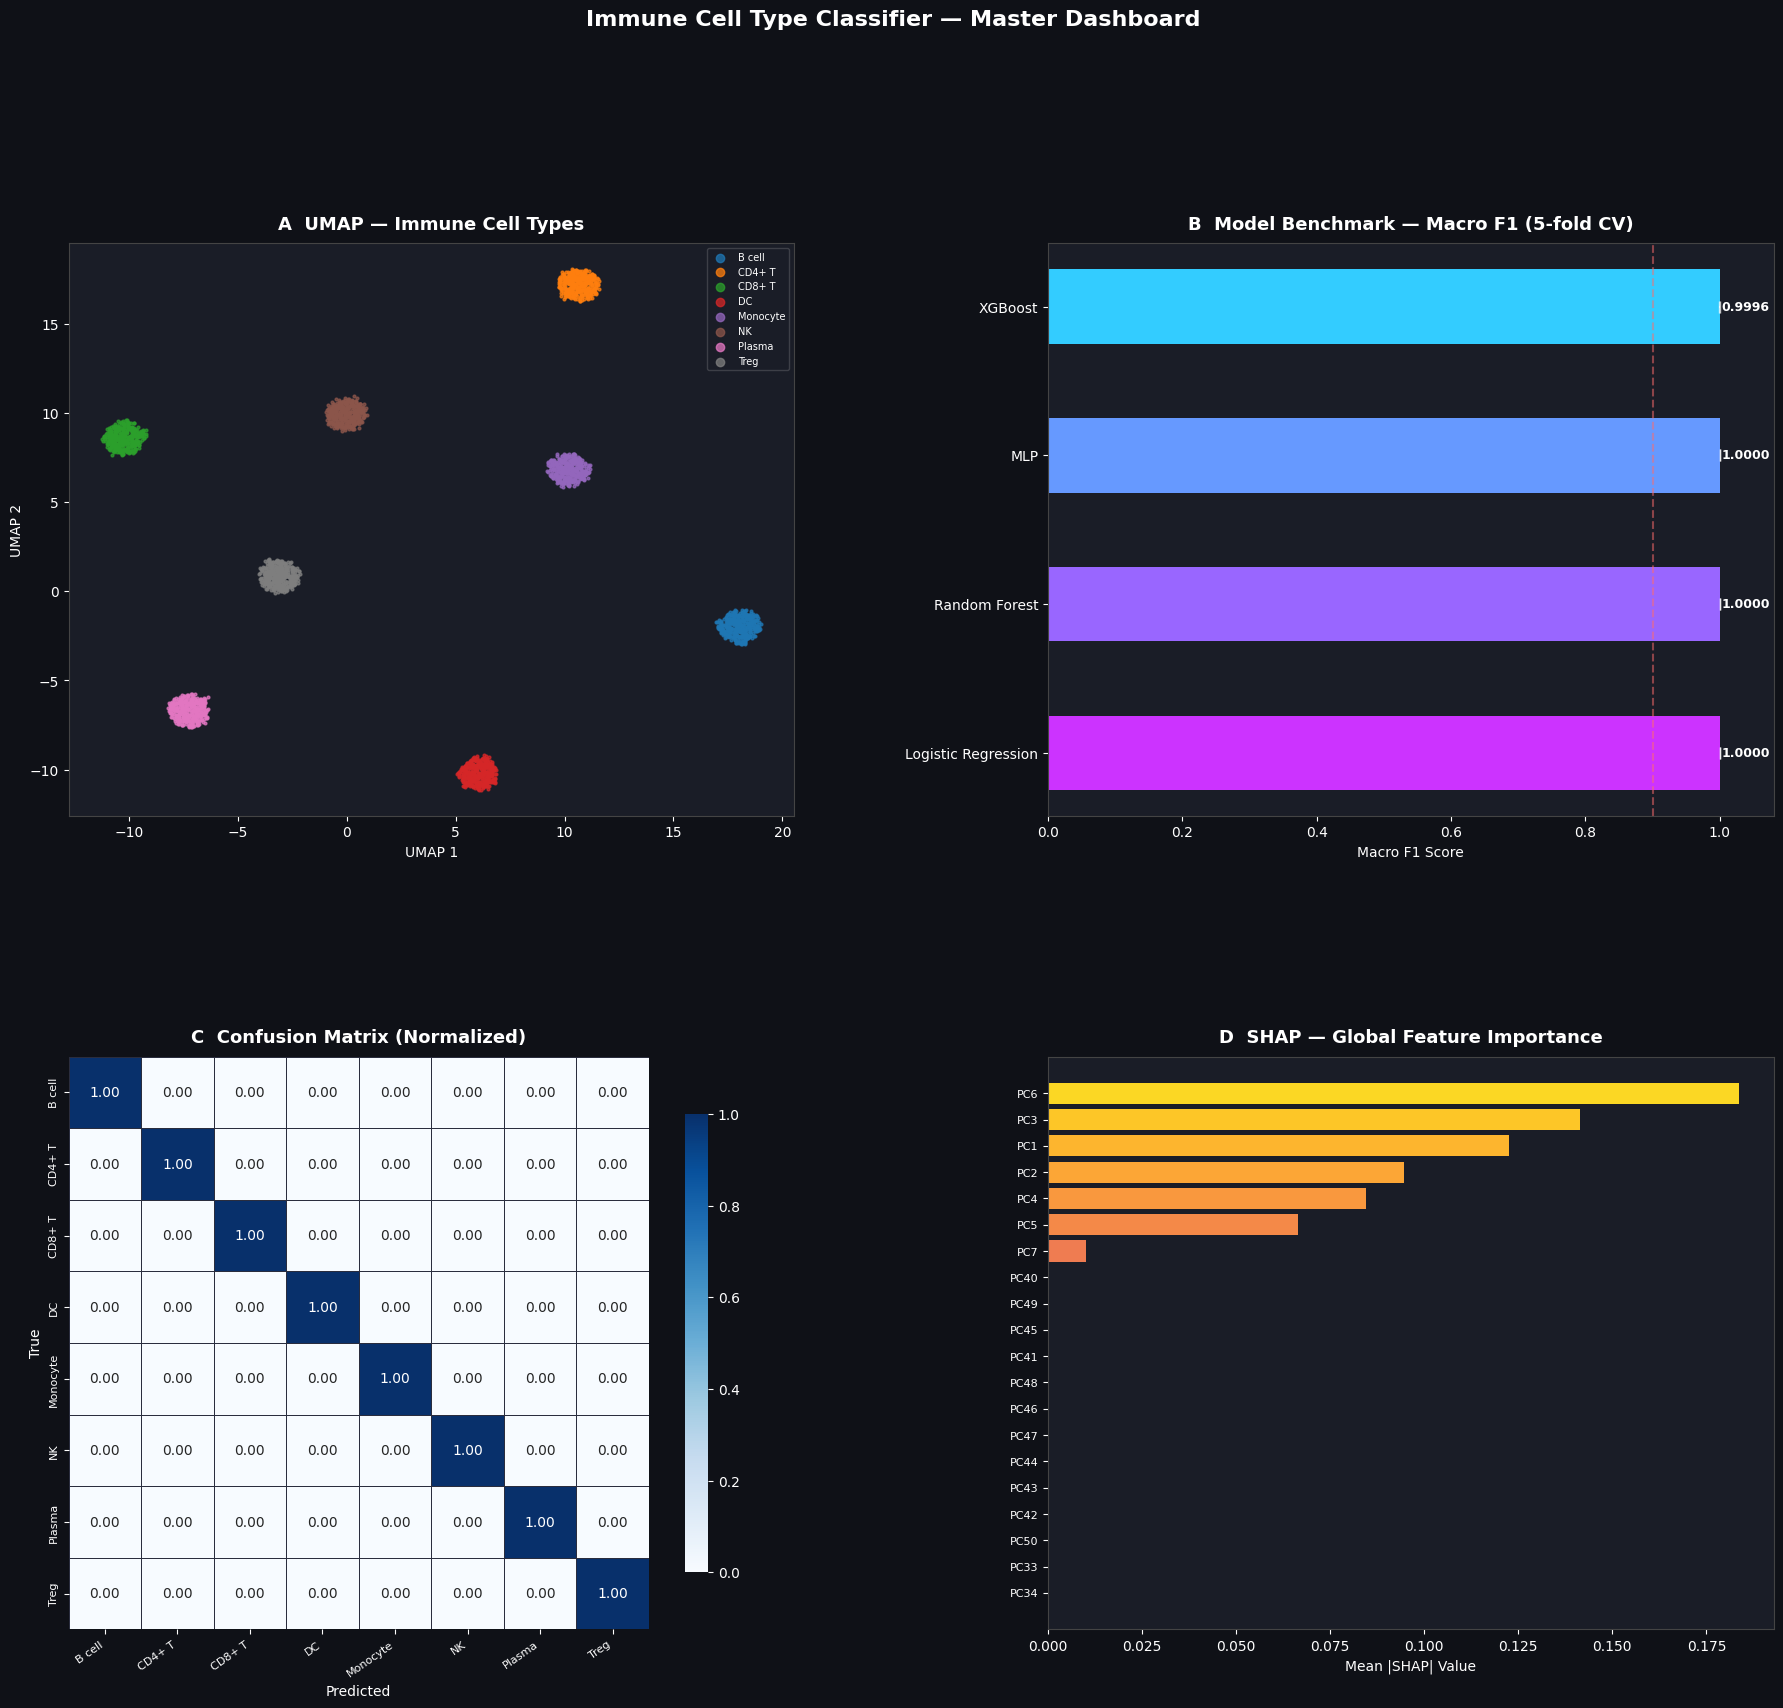

✅ Dashboard saved (PNG + PDF)


In [16]:
# Redeclare Cell 13 variables explicitly — makes this dashboard cell
# self-contained if Cell 13 was skipped or the kernel was interrupted.
coords    = adata.obsm["X_umap"]
types     = adata.obs["cell_type"].values
_palette  = sns.color_palette("tab10", n_colors=len(adata.obs["cell_type"].cat.categories))
color_map = dict(zip(
    adata.obs["cell_type"].cat.categories,
    [f"#{int(r*255):02x}{int(g*255):02x}{int(b*255):02x}" for r, g, b in _palette]
))
# Guard upstream dependencies with try/except NameError — dir() only sees
# local scope in Jupyter so it cannot detect variables from other cells.
try:
    cm_norm
except NameError:
    cm_norm = confusion_matrix(y_test, y_pred, normalize='true')
try:
    feat_importance, top_k, top_idx
except NameError:
    raise RuntimeError('Run Cell 29 (SHAP) before the dashboard')
try:
    benchmark_df
except NameError:
    raise RuntimeError('Run Cell 17 (Benchmark) before the dashboard')

fig = plt.figure(figsize=(22, 18))
fig.patch.set_facecolor("#0f1117")
gs  = gridspec.GridSpec(2, 2, figure=fig, hspace=0.42, wspace=0.35)

# ── A: UMAP ────────────────────────────────────────────────────────────────
ax_umap = fig.add_subplot(gs[0, 0])
ax_umap.set_facecolor("#1a1d27")
for ct in adata.obs["cell_type"].cat.categories:
    mask = types == ct
    ax_umap.scatter(coords[mask, 0], coords[mask, 1],
                    s=4, alpha=0.75, label=ct,
                    color=color_map.get(ct, "gray"), rasterized=True)
ax_umap.set_title("A  UMAP — Immune Cell Types",
                  color="white", fontsize=13, pad=10, weight="bold")
ax_umap.set_xlabel("UMAP 1", color="white")
ax_umap.set_ylabel("UMAP 2", color="white")
for sp in ax_umap.spines.values(): sp.set_edgecolor("#444")
leg = ax_umap.legend(fontsize=7, loc="upper right", framealpha=0.2,
                     labelcolor="white", markerscale=3)
leg.get_frame().set_facecolor("#1a1d27")

# ── B: Benchmark ────────────────────────────────────────────────────────────
ax_bench = fig.add_subplot(gs[0, 1])
ax_bench.set_facecolor("#1a1d27")
bench_pal2 = sns.color_palette("cool", n_colors=len(benchmark_df))[::-1]
bars2 = ax_bench.barh(benchmark_df["Model"], benchmark_df["F1 Macro (mean)"],
                      xerr=benchmark_df["F1 Macro (std)"],
                      color=bench_pal2, height=0.5, capsize=4,
                      error_kw=dict(ecolor="white", alpha=0.7))
for bar, val in zip(bars2, benchmark_df["F1 Macro (mean)"]):
    ax_bench.text(val + 0.003, bar.get_y() + bar.get_height() / 2,
                  f"{val:.4f}", va="center", color="white", fontsize=9, weight="bold")
ax_bench.set_xlim(0, 1.08)
ax_bench.set_title("B  Model Benchmark — Macro F1 (5-fold CV)",
                   color="white", fontsize=13, pad=10, weight="bold")
ax_bench.set_xlabel("Macro F1 Score", color="white")
ax_bench.axvline(0.9, color="#ff6b6b", linestyle="--", alpha=0.5)
for sp in ax_bench.spines.values(): sp.set_edgecolor("#444")

# ── C: Confusion Matrix ─────────────────────────────────────────────────────
ax_cm = fig.add_subplot(gs[1, 0])
ax_cm.set_facecolor("#1a1d27")
sns.heatmap(cm_norm, annot=True, fmt=".2f", cmap="Blues",
            xticklabels=le.classes_, yticklabels=le.classes_,
            ax=ax_cm, linewidths=0.5, linecolor="#2a2d3e",
            cbar_kws={"shrink": 0.8})
ax_cm.set_title("C  Confusion Matrix (Normalized)",
                color="white", fontsize=13, pad=10, weight="bold")
ax_cm.set_xlabel("Predicted", color="white")
ax_cm.set_ylabel("True",      color="white")
ax_cm.tick_params(colors="white", labelsize=8)
ax_cm.set_xticklabels(le.classes_, rotation=35, ha="right")
for sp in ax_cm.spines.values(): sp.set_edgecolor("#444")

# ── D: SHAP global importance ─────────────────────────────────────────────
ax_shap = fig.add_subplot(gs[1, 1])
ax_shap.set_facecolor("#1a1d27")
bar_c2 = plt.cm.plasma(np.linspace(0.15, 0.92, top_k))
ax_shap.barh(range(top_k), feat_importance[top_idx][::-1], color=bar_c2)
ax_shap.set_yticks(range(top_k))
ax_shap.set_yticklabels([feature_names[i] for i in top_idx][::-1], fontsize=8)
ax_shap.set_title("D  SHAP — Global Feature Importance",
                  color="white", fontsize=13, pad=10, weight="bold")
ax_shap.set_xlabel("Mean |SHAP| Value", color="white")
for sp in ax_shap.spines.values(): sp.set_edgecolor("#444")

plt.suptitle("Immune Cell Type Classifier — Master Dashboard",
             color="white", fontsize=16, y=1.01, weight="bold")
plt.tight_layout()

# Save PNG for notebooks and PDF for vector-quality publication figures
plt.savefig(FIG_DIR / "dashboard.png", dpi=150, bbox_inches="tight",
            facecolor="#0f1117")
plt.savefig(FIG_DIR / "dashboard.pdf", bbox_inches="tight",
            facecolor="#0f1117")
plt.show()
plt.close()  # release figure memory
print("✅ Dashboard saved (PNG + PDF)")


---
## 📝 Section 15 — Results Summary & Next Steps

In [17]:
print("=" * 60)
print("  RESULTS SUMMARY")
print("=" * 60)
_dataset_label = "Synthetic demo data" if _using_demo else "Human Immune Multiomics Atlas"
print(f"  Dataset        : {_dataset_label}")
print(f"  Cells          : {adata.n_obs:,}")
print(f"  Genes (HVG)    : {adata.n_vars:,}")
print(f"  Feature space  : PCA ({X.shape[1]} components)")
print(f"  Cell types     : {len(le.classes_)}")
print()
print(f"  Best model     : {best_model_name} (Optuna-tuned)")
# best_n captured from the early-stopping probe — final_model trains without
# early stopping so .best_iteration is undefined on it.
print(f"  Trees (best_n) : {best_n}")
print(f"  Test F1 Macro  : {f1:.4f}")
print(f"  Test ROC-AUC   : {roc_auc:.4f}")
print()

# Save model + preprocessing artifacts for reloading without full re-run
joblib.dump(final_model, OUT_DIR / "xgb_final_model.pkl")
joblib.dump(pca_ml,      OUT_DIR / "pca_ml.pkl")
joblib.dump(le,          OUT_DIR / "label_encoder.pkl")
print("  Artifacts saved:")
print("    xgb_final_model.pkl  — trained XGBoost classifier")
print(f"    pca_ml.pkl           — fitted PCA transformer ({n_comps_ml} PCs)")
print("    label_encoder.pkl    — LabelEncoder (int ↔ cell type name)")
print()

# Walk restricted to output dirs — /kaggle/working also contains pip cache
# and __pycache__ which would flood the output listing.
print(f"  Output files:")
for target_dir in [OUT_DIR, FIG_DIR]:
    for root, dirs, files in os.walk(target_dir):
        dirs[:] = [d for d in dirs if not d.startswith(".")]
        for fname in sorted(files):
            full = os.path.join(root, fname)
            size = os.path.getsize(full)
            rel  = os.path.relpath(full, OUT_DIR.parent)
            print(f"    {rel:<45} {size/1024:6.1f} KB")
print("=" * 60)


  RESULTS SUMMARY
  Dataset        : Synthetic demo data
  Cells          : 3,000
  Genes (HVG)    : 2,000
  Feature space  : PCA (50 components)
  Cell types     : 8

  Best model     : Logistic Regression (Optuna-tuned)
  Trees (best_n) : 10
  Test F1 Macro  : 1.0000
  Test ROC-AUC   : 1.0000

  Artifacts saved:
    xgb_final_model.pkl  — trained XGBoost classifier
    pca_ml.pkl           — fitted PCA transformer (50 PCs)
    label_encoder.pkl    — LabelEncoder (int ↔ cell type name)

  Output files:
    outputs/benchmark_results.csv                    0.2 KB
    outputs/classification_report.csv                0.3 KB
    outputs/label_encoder.pkl                        0.5 KB
    outputs/optuna_trials.csv                       21.1 KB
    outputs/pca_ml.pkl                             399.9 KB
    outputs/xgb_final_model.pkl                     66.4 KB
    figures/benchmark.png                           40.2 KB
    figures/confusion_matrix.png                    87.0 KB
    figures

---
## 🚀 Next Steps

| Direction | Description | Tools |
|:---|:---|:---|
| **Multi-omics fusion** | Integrate ATAC-seq / proteomics alongside RNA | `Muon`, `WNN` |
| **Graph Neural Network** | Model cells as nodes in k-NN graph | `PyG`, `DGL` |
| **Batch correction** | Harmonize across donors / batches | `Harmony`, `scVI` |
| **Trajectory analysis** | Infer developmental lineages | `scVelo`, `CellRank` |
| **REST API** | Serve the model for new cell classification | `FastAPI`, `Docker` |
| **Differential expression** | Find marker genes per cluster | `DESeq2`, `diffxpy` |

---

> 🧬 **Portfolio note:** This notebook demonstrates the full production ML stack —  
> preprocessing → benchmarking → Bayesian tuning → explainability — applied to  
> cutting-edge single-cell genomics data. The same pipeline generalizes to  
> cancer immunotherapy, autoimmune disease, and drug target discovery contexts.
